### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

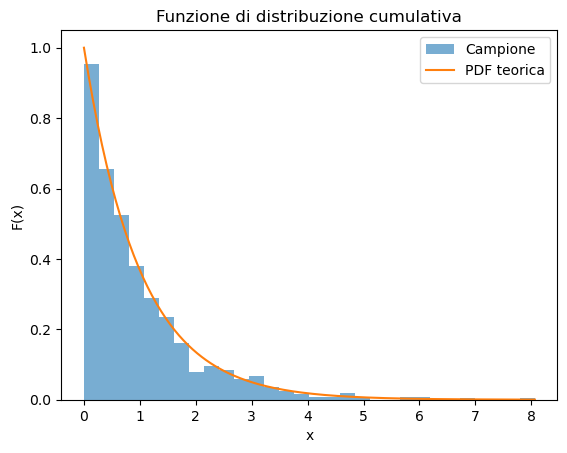

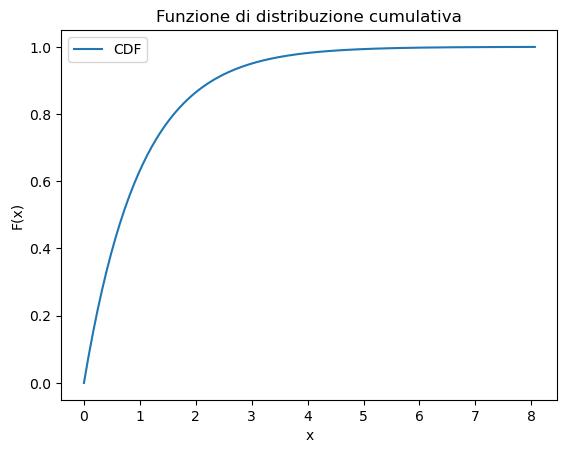

Varianza teorica: 1.0
Varianza campionaria: 1.0126185306903623


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import sklearn

#1 congelo la distribuzione gamma con parametro di forma = 1
X = st.gamma(1)

#2 genero 1000 valori casuali
sample = X.rvs(size=1000)

#3 Istogramma + PDF
xs = np.linspace(0, sample.max(), 200)

plt.hist(sample, bins=30, density=True, alpha=0.6, label="Campione")
plt.plot(xs, X.pdf(xs), label="PDF teorica")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Funzione di distribuzione cumulativa")
plt.legend()
plt.show()

#CDF
plt.plot(xs, X.cdf(xs), label="CDF")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Funzione di distribuzione cumulativa")
plt.legend()
plt.show()

#Varianza
var_teorica = X.var()
var_campione = np.var(sample)

print("Varianza teorica:", var_teorica)
print("Varianza campionaria:", var_campione)

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

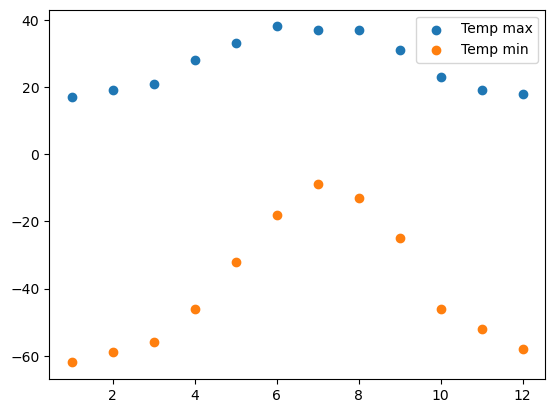

MAX
MAE = 0.772055333487906
RMSE = 0.8479022664866749

MIN
MAE = 2.3410117532483974
RMSE = 2.697276717085529


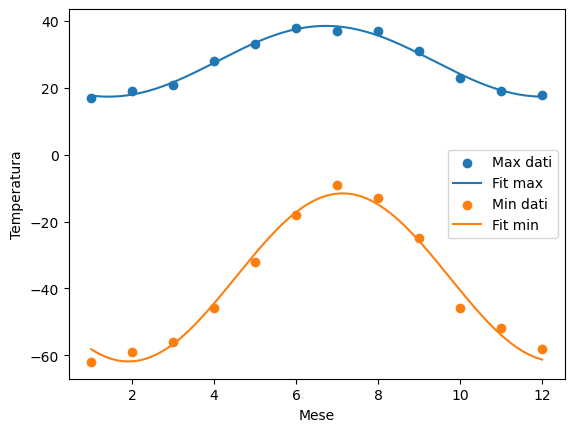

In [3]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt


mesi = np.arange(1, 13)

#Visualizzazione dati
plt.scatter(mesi, temp_max, label="Temp max")
plt.scatter(mesi, temp_min, label="Temp min")
plt.legend()
plt.show()

#Definizione funzione sinusoidale
from scipy.optimize import curve_fit

def sinusoid(x, A, B, C, D):
    return A * np.sin(B * x + C) + D

#Fit dei dati
#temperature massime
popt_max, _ = curve_fit(
    sinusoid,
    mesi,
    temp_max,
    p0=[10, 2*np.pi/12, 0, np.mean(temp_max)]
)

pred_max = sinusoid(mesi, *popt_max)


#temperature minime
popt_min, _ = curve_fit(
    sinusoid,
    mesi,
    temp_min,
    p0=[30, 2*np.pi/12, 0, np.mean(temp_min)]
)

pred_min = sinusoid(mesi, *popt_min)

#Calcolo MAE e RMSE
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae_max = mean_absolute_error(temp_max, pred_max)
rmse_max = root_mean_squared_error(temp_max, pred_max)

mae_min = mean_absolute_error(temp_min, pred_min)
rmse_min = root_mean_squared_error(temp_min, pred_min)

print("MAX")
print("MAE =", mae_max)
print("RMSE =", rmse_max)

print("\nMIN")
print("MAE =", mae_min)
print("RMSE =", rmse_min)

#grafico finale
xs = np.linspace(1, 12, 200)

plt.scatter(mesi, temp_max, label="Max dati")
plt.plot(xs, sinusoid(xs, *popt_max), label="Fit max")

plt.scatter(mesi, temp_min, label="Min dati")
plt.plot(xs, sinusoid(xs, *popt_min), label="Fit min")

plt.xlabel("Mese")
plt.ylabel("Temperatura")
plt.legend()
plt.show()

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

Coefficiente: -0.04121511996278612
Intercetta: 29.599854756163946


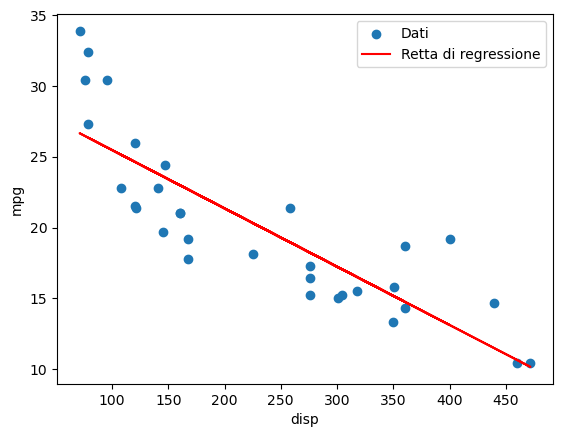

R² = 0.7183433404897299


In [2]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df

# Seleziono colonne
X = df[["disp"]]
y = df["mpg"]

# Creo il modello
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

#Stampa coefficiente e intercetta
print("Coefficiente:", model.coef_[0])
print("Intercetta:", model.intercept_)

#Predizioni
y_pred = model.predict(X)

#Grafico
import matplotlib.pyplot as plt

plt.scatter(X, y, label="Dati")
plt.plot(X, y_pred, color="red", label="Retta di regressione")

plt.xlabel("disp")
plt.ylabel("mpg")
plt.legend()

plt.show()

#Calcolo R^2
r2 = model.score(X, y)

print("R² =", r2)